# Evalution — Análise de Resultados

## Objetivo

Avaliar onde o modelo acerta, onde erra e qual o impacto desses erros para o negócio.

In [1]:
import joblib
import pandas as pd

In [11]:
preprocessor = joblib.load("/home/tatiane/repositorios/data-projects/03_machine_learning/etl_customer_value_classfication/raw/model_input/preprocessor.pkl")

X_test = pd.read_csv("/home/tatiane/repositorios/data-projects/03_machine_learning/etl_customer_value_classfication/raw/model_input/X_test.csv")
y_test = pd.read_csv("/home/tatiane/repositorios/data-projects/03_machine_learning/etl_customer_value_classfication/raw/model_input/y_test.csv").squeeze()
X_train = pd.read_csv("/home/tatiane/repositorios/data-projects/03_machine_learning/etl_customer_value_classfication/raw/model_input/X_train.csv")
y_train = pd.read_csv("/home/tatiane/repositorios/data-projects/03_machine_learning/etl_customer_value_classfication/raw/model_input/y_train.csv").squeeze()

#### Métricas globais finais

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [13]:
from sklearn.metrics import classification_report

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    print(classification_report(y, y_pred))

evaluate_model(pipeline, X_test, y_test)

              precision    recall  f1-score   support

  High_Value       1.00      0.98      0.99       676
   Low_Value       1.00      0.98      0.99       675
Medium_Value       0.96      0.99      0.98       675

    accuracy                           0.98      2026
   macro avg       0.99      0.98      0.98      2026
weighted avg       0.99      0.98      0.98      2026



#### Matriz de confusão

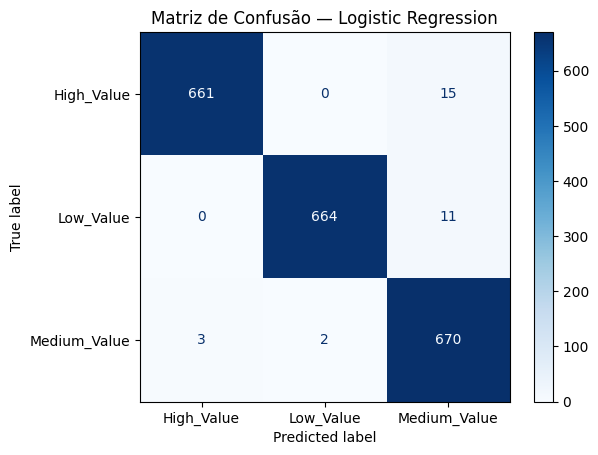

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap="Blues",
    values_format="d"
)
plt.title("Matriz de Confusão — Logistic Regression")
plt.show()

### Análise dos erros

In [15]:
errors = X_test.copy()
errors["y_true"] = y_test
errors["y_pred"] = y_pred

errors["error"] = errors["y_true"] != errors["y_pred"]
errors[errors["error"] == True].head()

,Total_Trans_Amt,Total_Trans_Ct,Credit_Limit,Months_on_book,Months_Inactive_12_mon,y_true,y_pred,error
47,0.115445,0.418605,0.068436,0.488372,0.333333,Low_Value,Medium_Value,True
165,0.237120,0.511628,0.056464,0.418605,0.166667,High_Value,Medium_Value,True
188,0.097530,0.387597,0.132769,0.255814,0.166667,Low_Value,Medium_Value,True
248,0.223990,0.550388,0.041046,0.534884,0.833333,Low_Value,Medium_Value,True
292,0.077000,0.356589,0.056192,0.837209,0.333333,Low_Value,Medium_Value,True


### Impacto de negócio dos erros

In [16]:
pd.crosstab(
    errors["y_true"],
    errors["y_pred"],
    normalize="index"
)

y_pred,High_Value,Low_Value,Medium_Value
y_true,,,
High_Value,0.977811,0.000000,0.022189
Low_Value,0.000000,0.983704,0.016296
Medium_Value,0.004444,0.002963,0.992593


### Análise qualitativa dos resultados

A avaliação do modelo indica desempenho elevado e consistente na segmentação de clientes em Low, Medium e High Value, conforme evidenciado pelo F1-score macro próximo de 0.98 e métricas equilibradas entre as classes.

A análise da matriz de confusão mostra que a maior parte dos erros ocorre entre as classes Medium_Value e High_Value, caracterizando zonas de transição natural entre segmentos adjacentes. Esse comportamento é esperado em problemas de classificação multiclasse baseados em score contínuo.

Não foram observados erros relevantes de classificação direta entre Low_Value e High_Value, o que reduz significativamente o risco de decisões estratégicas equivocadas, como a priorização indevida de clientes de baixo valor ou a exclusão de clientes de alto valor de ações estratégicas.

Do ponto de vista de negócio, os erros identificados apresentam impacto moderado, uma vez que confusões entre classes intermediárias tendem a afetar apenas o nível de priorização, e não decisões críticas.

- Os resultados obtidos no conjunto de teste são coerentes com a validação cruzada, cujo desempenho médio apresentou leve redução em relação ao hold-out, indicando uma estimativa mais conservadora e realista da capacidade de generalização do modelo.

### Conclusão Final do projeto

Este projeto teve como objetivo desenvolver uma abordagem analítica para a classificação de clientes com base em seu valor para o negócio, utilizando variáveis comportamentais e financeiras.

A criação de um target derivado permitiu estruturar uma segmentação clara e alinhada a critérios de negócio, enquanto o processo de feature engineering assegurou consistência, reprodutibilidade e ausência de vazamento de informação.

Entre os modelos avaliados, a Regressão Logística apresentou melhor desempenho global, estabilidade na validação cruzada e maior interpretabilidade, sendo selecionada como modelo final. A superioridade do modelo linear indica que a relação entre as variáveis explicativas e o valor do cliente é predominantemente linear, o que favorece soluções mais simples e transparentes.

A análise dos erros revelou que eventuais inconsistências ocorrem majoritariamente entre classes adjacentes, com impacto limitado para o negócio, reforçando a adequação do modelo como ferramenta de apoio à decisão.

Como próximos passos, recomenda-se o monitoramento contínuo do desempenho do modelo, a incorporação de novas variáveis comportamentais e a avaliação do uso do score contínuo em estratégias mais granulares de segmentação.